# سوال دوم

- بخش اول

# بخش دوم

# ۲-۲-الف)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


In [ ]:
class PatchEmbed(nn.Module):
    def __init__(self, img_size=32, patch_size=4, in_chans=3, embed_dim=256):
        super().__init__()
        self.n_patches = (img_size // patch_size) ** 2
        self.proj = nn.Conv2d(
            in_chans, embed_dim,
            kernel_size=patch_size,
            stride=patch_size)

    def forward(self, x):
        x = self.proj(x)     
        x = x.flatten(2)  
        x = x.transpose(1, 2)  
        return x

In [ ]:
class Attention(nn.Module):
    def __init__(self, dim, n_heads=8, qkv_bias=True, attn_drop=0.1, proj_drop=0.1):
        super().__init__()
        assert dim % n_heads == 0
        self.n_heads = n_heads
        self.head_dim = dim // n_heads
        self.scale = self.head_dim ** -0.5

        self.qkv = nn.Linear(dim, dim * 3, bias=qkv_bias)
        self.attn_drop = nn.Dropout(attn_drop)
        self.proj = nn.Linear(dim, dim)
        self.proj_drop = nn.Dropout(proj_drop)

    def forward(self, x):
        B, N, C = x.shape
        qkv = self.qkv(x).reshape(
            B, N, 3, self.n_heads, self.head_dim
        ).permute(2, 0, 3, 1, 4)

        q, k, v = qkv[0], qkv[1], qkv[2]

        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)
        attn = self.attn_drop(attn)

        x = (attn @ v).transpose(1, 2).reshape(B, N, C)
        x = self.proj(x)
        x = self.proj_drop(x)
        return x

In [ ]:
class MLP(nn.Module):
    def __init__(self, in_features, hidden_features, drop=0.1):
        super().__init__()
        self.fc1 = nn.Linear(in_features, hidden_features)
        self.act = nn.GELU()
        self.fc2 = nn.Linear(hidden_features, in_features)
        self.drop = nn.Dropout(drop)

    def forward(self, x):
        x = self.fc1(x)
        x = self.act(x)
        x = self.drop(x)
        x = self.fc2(x)
        x = self.drop(x)
        return x

In [ ]:
class TransformerBlock(nn.Module):
    def __init__(self, dim, n_heads, mlp_ratio=4.0, drop=0.1, attn_drop=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = Attention(dim, n_heads, attn_drop=attn_drop, proj_drop=drop)
        self.norm2 = nn.LayerNorm(dim)

        mlp_hidden = int(dim * mlp_ratio)
        self.mlp = MLP(dim, mlp_hidden, drop)

    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x

In [ ]:
class ViT(nn.Module):
    def __init__(
        self,
        img_size=32,
        patch_size=4,
        in_chans=3,
        num_classes=10,
        embed_dim=256,
        depth=6,
        n_heads=8,
        mlp_ratio=4.0,
        drop=0.1,
        attn_drop=0.1):
        super().__init__()

        self.patch_embed = PatchEmbed(img_size, patch_size, in_chans, embed_dim)
        n_patches = self.patch_embed.n_patches

        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, n_patches + 1, embed_dim))
        self.pos_drop = nn.Dropout(drop)

        self.blocks = nn.ModuleList([
            TransformerBlock(
                embed_dim, n_heads, mlp_ratio, drop, attn_drop
            ) for _ in range(depth)
        ])

        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)

        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

    def forward(self, x):
        B = x.shape[0]
        x = self.patch_embed(x)

        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)

        x = x + self.pos_embed
        x = self.pos_drop(x)

        for blk in self.blocks:
            x = blk(x)

        x = self.norm(x)
        cls_out = x[:, 0]
        return self.head(cls_out)

    def get_layer_features(self, x):
        B = x.shape[0]
        x = self.patch_embed(x)
        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)
        x = x + self.pos_embed
        x = self.pos_drop(x)
    
        features = []
        features.append(x[:, 0].clone())
    
        for blk in self.blocks:
            x = blk(x)
            features.append(x[:, 0].clone())
    
        x = self.norm(x)
        features.append(x[:, 0].clone())
    
        return features

# ۲-۲-ب)

In [ ]:
train_transform = transforms.Compose([
    transforms.RandomRotation(20),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

full_train = datasets.CIFAR10(root='./data', train=True, download=True, transform=train_transform)
test_data = datasets.CIFAR10(root='./data', train=False, download=True, transform=test_transform)

train_idx, val_idx = train_test_split(
    np.arange(len(full_train)),
    test_size=0.2,
    stratify=full_train.targets,
    random_state=42
)

train_data = Subset(full_train, train_idx)
val_data_temp = Subset(full_train, val_idx)

val_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=test_transform)
val_data = Subset(val_dataset, val_idx)

train_loader = DataLoader(train_data, batch_size=200, shuffle=True, num_workers=2)
val_loader = DataLoader(val_data, batch_size=200, shuffle=False, num_workers=2)
test_loader = DataLoader(test_data, batch_size=200, shuffle=False, num_workers=2)

print(f'Train: {len(train_data)}, Val: {len(val_data)}, Test: {len(test_data)}')

100%|██████████| 170M/170M [00:03<00:00, 47.2MB/s]


Train: 40000, Val: 10000, Test: 10000


In [ ]:
def end_to_end_training(
    model,
    train_loader,
    val_loader,
    test_loader,
    epochs,
    device,
    save_path="best_vit.pth"
):
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

    optimizer = optim.AdamW(
        model.parameters(),
        lr=3e-4,
        weight_decay=5e-2
    )

    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=epochs
    )

    best_val_acc = 0.0
    best_val_loss = float("inf")

    train_losses, val_losses = [], []
    train_accs, val_accs, test_accs = [], [], []

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * labels.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        train_loss = running_loss / total
        train_acc = 100. * correct / total
        train_losses.append(train_loss)
        train_accs.append(train_acc)

        model.eval()
        val_running_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_running_loss += loss.item() * labels.size(0)
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()

        val_loss = val_running_loss / total
        val_acc = 100. * correct / total
        val_losses.append(val_loss)
        val_accs.append(val_acc)

        scheduler.step()

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), save_path)

        
        if (epoch + 1) % 10 == 0:
            print(
                f"Epoch {epoch+1}/{epochs} | "
                f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | "
                f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%"
            )

        test_acc = evaluate(model, test_loader, device)
        test_accs.append(test_acc)
        print(f"Test Acc after Epoch {epoch+1}: {test_acc:.2f}%")

    return train_losses, val_losses, train_accs, val_accs, test_accs

In [ ]:
def evaluate(model, loader, device):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    return 100. * correct / total

In [ ]:
print('Creating ViT model...')
model = ViT(
    img_size=32,
    patch_size=4,
    in_chans=3,
    num_classes=10,
    embed_dim=256,
    depth=12,     
    n_heads=8,
    mlp_ratio=4.0,
    drop=0.1,
    attn_drop=0.1
).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f'Total parameters: {total_params:,}')

print('\nTraining ViT (End-to-End)...')
train_losses, val_losses, train_accs, val_accs, test_accs  = end_to_end_training(
    model, train_loader, val_loader, test_loader, epochs=90, device=device
)

Creating ViT model...
Total parameters: 9,509,642

Training ViT (End-to-End)...
Test Acc after Epoch 1: 33.16%
Test Acc after Epoch 2: 46.32%
Test Acc after Epoch 3: 49.90%
Test Acc after Epoch 4: 54.19%
Test Acc after Epoch 5: 57.19%
Test Acc after Epoch 6: 60.69%
Test Acc after Epoch 7: 60.55%
Test Acc after Epoch 8: 62.13%
Test Acc after Epoch 9: 63.95%
Epoch 10/90 | Train Loss: 1.2803, Train Acc: 64.39% | Val Loss: 1.2368, Val Acc: 66.69%
Test Acc after Epoch 10: 64.89%
Test Acc after Epoch 11: 66.82%
Test Acc after Epoch 12: 65.35%
Test Acc after Epoch 13: 67.39%
Test Acc after Epoch 14: 67.62%
Test Acc after Epoch 15: 69.79%
Test Acc after Epoch 16: 70.01%
Test Acc after Epoch 17: 69.03%
Test Acc after Epoch 18: 70.50%
Test Acc after Epoch 19: 71.50%
Epoch 20/90 | Train Loss: 1.0804, Train Acc: 73.55% | Val Loss: 1.1177, Val Acc: 72.62%
Test Acc after Epoch 20: 71.62%
Test Acc after Epoch 21: 69.86%
Test Acc after Epoch 22: 71.21%
Test Acc after Epoch 23: 72.19%
Test Acc after Ep


Test Accuracy: 76.85%


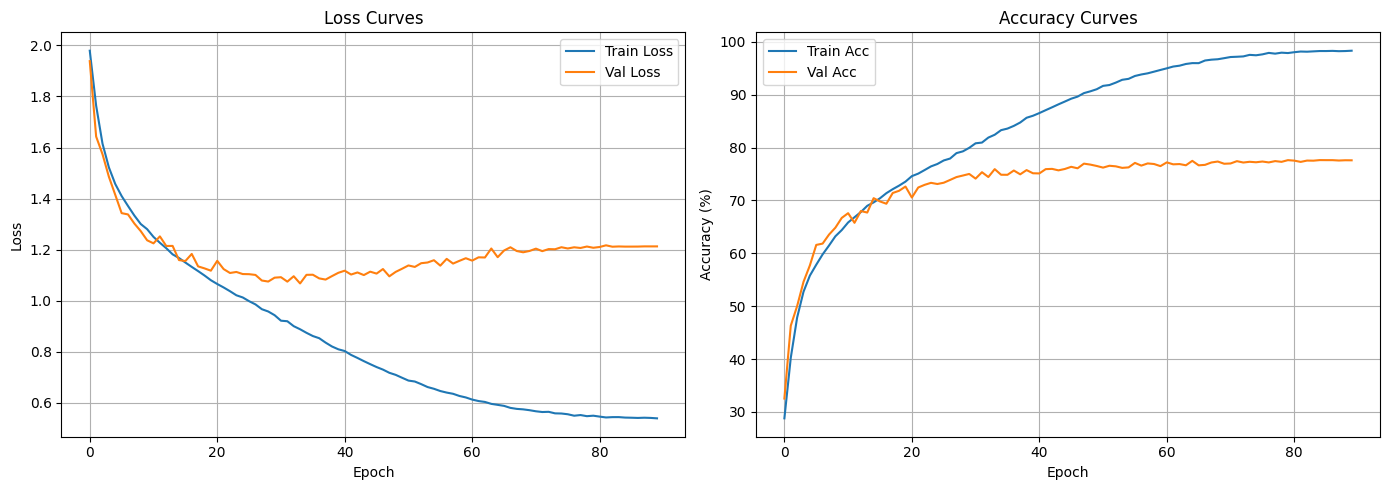

In [11]:
test_acc = evaluate(model, test_loader, device)
print(f'\nTest Accuracy: {test_acc:.2f}%')

def plot_training(train_losses, val_losses, train_accs, val_accs):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(train_losses, label='Train Loss')
    axes[0].plot(val_losses, label='Val Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Loss Curves')
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(train_accs, label='Train Acc')
    axes[1].plot(val_accs, label='Val Acc')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy (%)')
    axes[1].set_title('Accuracy Curves')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.savefig('training_curves.png', dpi=150)
    plt.show()

plot_training(train_losses, val_losses, train_accs, val_accs)

# ۲-۲-ج)

In [ ]:
def compute_si(features, labels, metric='euclidean'):
    X = features.numpy()
    y = labels.numpy()

    nbrs = NearestNeighbors(n_neighbors=2, metric=metric).fit(X)
    distances, indices = nbrs.kneighbors(X)

    # index 0 is itself, 1 is nearest neighbor
    nn_indices = indices[:, 1]
    si = np.mean(y == y[nn_indices])

    return si

In [ ]:
def get_class_token_features(model, loader, device):
    model.eval()
    layer_features = {i: [] for i in range(len(model.blocks) + 2)}
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            all_labels.append(labels)

            B = images.shape[0]
            x = model.patch_embed(images)
            cls_tokens = model.cls_token.expand(B, -1, -1)
            x = torch.cat([cls_tokens, x], dim=1)
            x = x + model.pos_embed
            x = model.pos_drop(x)

            layer_features[0].append(x[:, 0].cpu())

            for i, block in enumerate(model.blocks):
                x = block(x)
                layer_features[i + 1].append(x[:, 0].cpu())

            x_norm = model.norm(x)
            layer_features[len(model.blocks) + 1].append(x_norm[:, 0].cpu())

    all_labels = torch.cat(all_labels)
    for key in layer_features:
        layer_features[key] = torch.cat(layer_features[key])

    return layer_features, all_labels

Layer 0: SI = 0.1000
Layer 1: SI = 0.3752
Layer 2: SI = 0.4906
Layer 3: SI = 0.5738
Layer 4: SI = 0.6285
Layer 5: SI = 0.6526
Layer 6: SI = 0.6774
Layer 7: SI = 0.6903
Layer 8: SI = 0.6943
Layer 9: SI = 0.6975
Layer 10: SI = 0.7043
Layer 11: SI = 0.7085
Layer 12: SI = 0.7023
Layer 13: SI = 0.7443


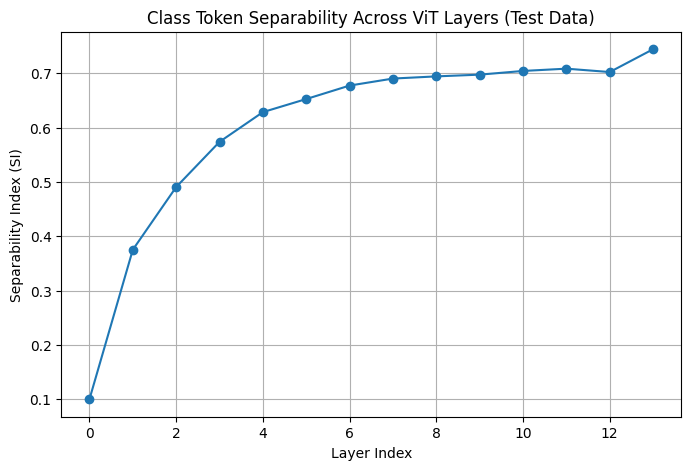

In [ ]:
test_features, test_labels = get_class_token_features(
    model, test_loader, device
)

si_per_layer = []
num_layers = len(test_features)

for i in range(num_layers):
    feats = test_features[i]
    si = compute_si(feats, test_labels)
    si_per_layer.append(si)
    print(f'Layer {i}: SI = {si:.4f}')


plt.figure(figsize=(8, 5))
plt.plot(si_per_layer, marker='o')
plt.xlabel('Layer Index')
plt.ylabel('Separability Index (SI)')
plt.title('Class Token Separability Across ViT Layers (Test Data)')
plt.grid(True)
plt.show()

# ۲-۲-د)

In [ ]:
try:
    import umap
except:
    !pip install umap-learn
    import umap

def run_umap(features, n_neighbors=15, min_dist=0.1, random_state=42):
    reducer = umap.UMAP(
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        n_components=2,
        metric='euclidean',
        random_state=random_state)
    return reducer.fit_transform(features)

2026-01-08 17:09:58.358040: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1767892198.523277      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767892198.569693      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1767892198.960813      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767892198.960837      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767892198.960840      24 computation_placer.cc:177] computation placer alr

In [ ]:
def extract_last_layer_tokens(model, loader, device):
    model.eval()

    cls_features = []
    mean_features = []
    labels_all = []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            B = imgs.size(0)
            x = model.patch_embed(imgs)
            cls_tokens = model.cls_token.expand(B, -1, -1)
            x = torch.cat((cls_tokens, x), dim=1)
            x = x + model.pos_embed
            x = model.pos_drop(x)

            for blk in model.blocks:
                x = blk(x)

            x = model.norm(x)
            cls_feat = x[:, 0, :] 
            mean_feat = x[:, 1:, :].mean(dim=1)
            cls_features.append(cls_feat.cpu())
            mean_features.append(mean_feat.cpu())
            labels_all.append(labels)
            
    cls_features = torch.cat(cls_features, dim=0)
    mean_features = torch.cat(mean_features, dim=0)
    labels_all = torch.cat(labels_all, dim=0)
    return cls_features, mean_features, labels_all

def plot_umap(embeddings, labels, title):
    plt.scatter(
        embeddings[:, 0],
        embeddings[:, 1],
        c=labels,
        cmap='tab10',
        s=8,
        alpha=0.8)
    plt.colorbar()
    plt.title(title)
    plt.axis('off')

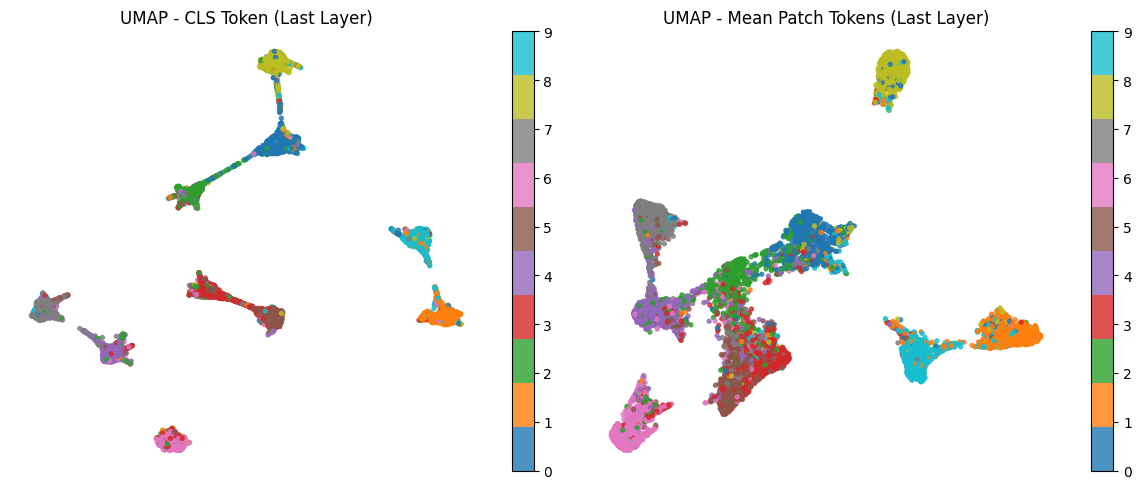

In [ ]:
cls_feats, mean_feats, test_labels = extract_last_layer_tokens(
    model, test_loader, device
)

cls_umap = run_umap(cls_feats.numpy())
mean_umap = run_umap(mean_feats.numpy())

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plot_umap(cls_umap, test_labels, 'UMAP - CLS Token (Last Layer)')

plt.subplot(1, 2, 2)
plot_umap(mean_umap, test_labels, 'UMAP - Mean Patch Tokens (Last Layer)')

plt.tight_layout()
plt.show()

In [18]:
si_cls = compute_si(cls_feats, test_labels)
si_mean = compute_si(mean_feats, test_labels)

print(f'SI (CLS token):  {si_cls:.4f}')
print(f'SI (Mean token): {si_mean:.4f}')
print(f'SI Gain (CLS-Mean): {si_cls - si_mean:.4f}')

SI (CLS token):  0.7443
SI (Mean token): 0.7027
SI Gain (CLS-Mean): 0.0416


# بخش سوم

# ۲-۳-الف)

In [ ]:
def set_active_blocks(model, n_active_blocks):
    for p in model.parameters():
        p.requires_grad = False
    
    for p in model.patch_embed.parameters():
        p.requires_grad = True
    model.cls_token.requires_grad = True
    model.pos_embed.requires_grad = True

    for i, blk in enumerate(model.blocks):
        if i < n_active_blocks:
            for p in blk.parameters():
                p.requires_grad = True
                
    for p in model.head.parameters():
        p.requires_grad = True

def update_optimizer_params(optimizer, model, base_lr):
    active_params = set(
        p for p in model.parameters() if p.requires_grad)

    optimizer_params = set()
    for group in optimizer.param_groups:
        optimizer_params |= set(group["params"])

    new_params = list(active_params - optimizer_params)

    if len(new_params) > 0:
        optimizer.add_param_group({
            "params": new_params,
            "lr": base_lr * 2,
            "initial_lr": base_lr * 2})
        
def layerwise_training(
    model,
    train_loader,
    val_loader,
    test_loader,
    device,
    epochs_per_stage=20,
    blocks_per_stage=2,
    total_blocks=12,
    save_path="best_vit_layerwise.pth"
):
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = None
    all_train_losses, all_val_losses = [], []
    all_train_accs, all_val_accs = [], []
    all_test_accs = []
    stage_info = []
    base_lr = 1e-3
    best_val_acc = 0.0
    stages = total_blocks // blocks_per_stage

    for stage in range(stages):
        n_blocks = (stage + 1) * blocks_per_stage
        print(f"\nStage {stage+1}/{stages} → {n_blocks} blocks")
        stage_info.append({"stage": stage+1, "active_blocks": n_blocks})
        
        set_active_blocks(model, n_blocks)

        if optimizer is None:
            active_params = [p for p in model.parameters() if p.requires_grad]
            optimizer = optim.AdamW(
                active_params,
                lr=1e-3,
                weight_decay=1e-5
            )
        else:
            update_optimizer_params(optimizer, model, base_lr)

        scheduler = optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=epochs_per_stage
        )

        for epoch in range(epochs_per_stage):
            model.train()
            train_loss = 0.0
            correct, total = 0, 0

            for imgs, labels in train_loader:
                imgs, labels = imgs.to(device), labels.to(device)

                optimizer.zero_grad()
                out = model(imgs)
                loss = criterion(out, labels)
                loss.backward()
                optimizer.step()

                train_loss += loss.item() * labels.size(0)
                pred = out.argmax(1)
                total += labels.size(0)
                correct += pred.eq(labels).sum().item()

            train_loss /= total
            train_acc = 100 * correct / total

            model.eval()
            val_loss = 0.0
            correct, total = 0, 0
            with torch.no_grad():
                for imgs, labels in val_loader:
                    imgs, labels = imgs.to(device), labels.to(device)
                    out = model(imgs)
                    loss = criterion(out, labels)
                    val_loss += loss.item() * labels.size(0)

                    pred = out.argmax(1)
                    total += labels.size(0)
                    correct += pred.eq(labels).sum().item()

            val_loss /= total
            val_acc = 100 * correct / total
            scheduler.step()

            all_train_losses.append(train_loss)
            all_val_losses.append(val_loss)
            all_train_accs.append(train_acc)
            all_val_accs.append(val_acc)
            
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                torch.save(model.state_dict(), save_path)
        
            test_acc = evaluate(model, test_loader, device)
            all_test_accs.append(test_acc)
    
            print(f"Test Acc after Epoch {epoch+1}: {test_acc:.2f}%")

    return all_train_losses, all_val_losses, all_train_accs, all_val_accs, stage_info, all_test_accs

In [20]:
print('Creating ViT model...')
modelL2L = ViT(
    img_size=32,
    patch_size=4,
    in_chans=3,
    num_classes=10,
    embed_dim=256,
    depth=12,     
    n_heads=8,
    mlp_ratio=4.0,
    drop=0.1,
    attn_drop=0.1
).to(device)

total_params = sum(p.numel() for p in modelL2L.parameters())

print('\nTraining ViT («Layer-to-Layer)...')
all_train_losses, all_val_losses, all_train_accs, all_val_accs, stage_info, all_test_accs = layerwise_training(
    modelL2L,
    train_loader,
    val_loader,
    test_loader,
    device,
    epochs_per_stage=15,
    blocks_per_stage=2,
    total_blocks=12,
    save_path="best_vit_layerwise.pth"
)

Creating ViT model...

Training ViT («Layer-to-Layer)...

Stage 1/6 → 2 blocks
Test Acc after Epoch 1: 43.00%
Test Acc after Epoch 2: 51.11%
Test Acc after Epoch 3: 53.71%
Test Acc after Epoch 4: 54.49%
Test Acc after Epoch 5: 57.50%
Test Acc after Epoch 6: 58.13%
Test Acc after Epoch 7: 59.01%
Test Acc after Epoch 8: 61.29%
Test Acc after Epoch 9: 61.68%
Test Acc after Epoch 10: 63.92%
Test Acc after Epoch 11: 64.19%
Test Acc after Epoch 12: 65.35%
Test Acc after Epoch 13: 66.22%
Test Acc after Epoch 14: 66.52%
Test Acc after Epoch 15: 66.99%

Stage 2/6 → 4 blocks
Test Acc after Epoch 1: 66.07%
Test Acc after Epoch 2: 66.01%
Test Acc after Epoch 3: 66.72%
Test Acc after Epoch 4: 66.28%
Test Acc after Epoch 5: 66.78%
Test Acc after Epoch 6: 67.00%
Test Acc after Epoch 7: 66.84%
Test Acc after Epoch 8: 66.88%
Test Acc after Epoch 9: 66.92%
Test Acc after Epoch 10: 66.75%
Test Acc after Epoch 11: 66.68%
Test Acc after Epoch 12: 66.84%
Test Acc after Epoch 13: 67.05%
Test Acc after Epoch 

# ۲-۳-ب)

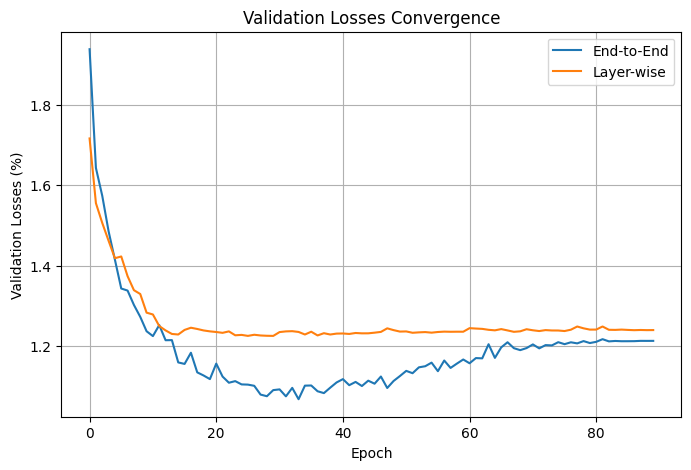

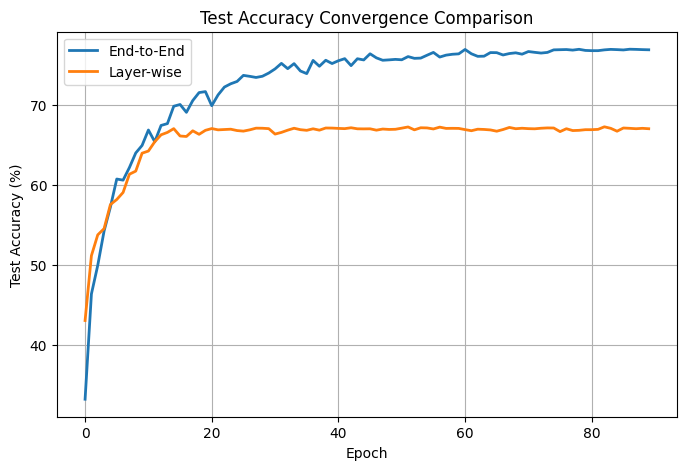

In [21]:
plt.figure(figsize=(8,5))
plt.plot(val_losses, label='End-to-End')
plt.plot(all_val_losses, label='Layer-wise')
plt.xlabel('Epoch')
plt.ylabel('Validation Losses (%)')
plt.title('Validation Losses Convergence')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))
plt.plot(test_accs, label='End-to-End', linewidth=2)
plt.plot(all_test_accs, label='Layer-wise', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Test Accuracy (%)')
plt.title('Test Accuracy Convergence Comparison')
plt.legend()
plt.grid(True)
plt.show()


# ۲-۳-ج)

In [22]:
def compute_cross_si(test_features, test_labels,
                     train_features, train_label,
                     metric='euclidean'):
    X_test = test_features.cpu().numpy()
    y_test = test_labels.cpu().numpy()
    X_train = train_features.cpu().numpy()
    y_train = train_labels.cpu().numpy()
    nn = NearestNeighbors(n_neighbors=1, metric=metric).fit(X_train)
    distances, indices = nn.kneighbors(X_test)
    nn_indices = indices[:, 0]
    correct = y_test == y_train[nn_indices]
    return np.mean(correct)

def compute_anti_si(features, labels, r=1,
                     metric='euclidean'):
    X = features.cpu().numpy()
    y = labels.cpu().numpy()
    nn = NearestNeighbors(n_neighbors=r + 1, metric=metric).fit(X)
    distances, indices = nn.kneighbors(X)
    nn_indices = indices[:, 1:]
    anti_hits = []
    for i in range(len(y)):
        neighbors = y[nn_indices[i]]
        if np.all(neighbors != y[i]):
            anti_hits.append(1)
        else:
            anti_hits.append(0)
    return np.mean(anti_hits)


def compute_center_si(features, labels, metric='euclidean'):
    X = features.cpu().numpy()
    y = labels.cpu().numpy()
    classes = np.unique(y)
    class_centers = np.stack([X[y == c].mean(axis=0) for c in classes], axis=0)
    nn = NearestNeighbors(n_neighbors=1, metric=metric).fit(class_centers)
    distances, indices = nn.kneighbors(X)
    pred_labels = classes[indices[:, 0]]
    return np.mean(pred_labels == y)

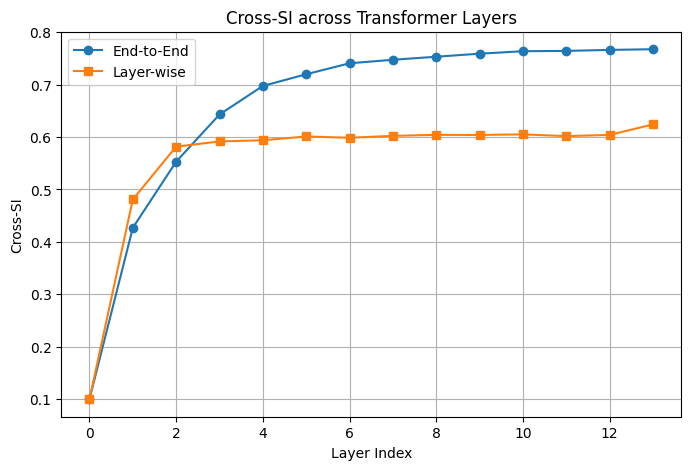

In [23]:
def extract_features(model, loader, device):
    model.eval()
    all_features = []
    all_labels = []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            layer_feats = model.get_layer_features(images)
            if len(all_features) == 0:
                all_features = [[] for _ in range(len(layer_feats))]
            for i, feat in enumerate(layer_feats):
                all_features[i].append(feat.cpu())
            all_labels.append(labels)

    all_labels = torch.cat(all_labels)
    for i in range(len(all_features)):
        all_features[i] = torch.cat(all_features[i])
    return all_features, all_labels
    
train_feats_e2e, train_labels = extract_features(model, train_loader, device)

test_feats_e2e, test_labels = extract_features(model, test_loader, device)

cross_si_e2e = []
for i in range(len(train_feats_e2e)):
    csi = compute_cross_si(
        test_feats_e2e[i], test_labels,
        train_feats_e2e[i], train_labels)
    cross_si_e2e.append(csi)


train_feats_lw, train_labels = extract_features(modelL2L, train_loader, device)

test_feats_lw, test_labels = extract_features(modelL2L, test_loader, device)

cross_si_lw = []
for i in range(len(train_feats_lw)):
    csi = compute_cross_si(
        test_feats_lw[i], test_labels,
        train_feats_lw[i], train_labels)
    cross_si_lw.append(csi)

layers = range(len(cross_si_e2e))

plt.figure(figsize=(8,5))
plt.plot(layers, cross_si_e2e, marker='o', label='End-to-End')
plt.plot(layers, cross_si_lw, marker='s', label='Layer-wise')
plt.xlabel('Layer Index')
plt.ylabel('Cross-SI')
plt.title('Cross-SI across Transformer Layers')
plt.legend()
plt.grid(True)
plt.show()

# ۲-۳-ه)

End-to-End vs Layer-wise Center-SI


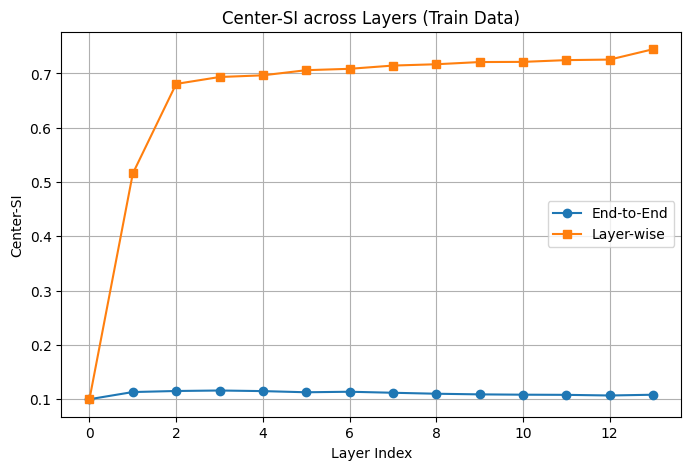

End-to-End Anti-SI


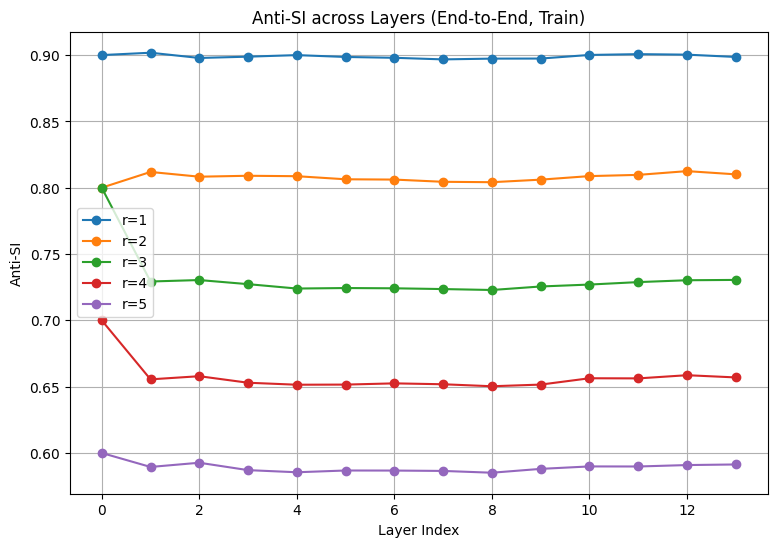

Layer-wise Anti-SI


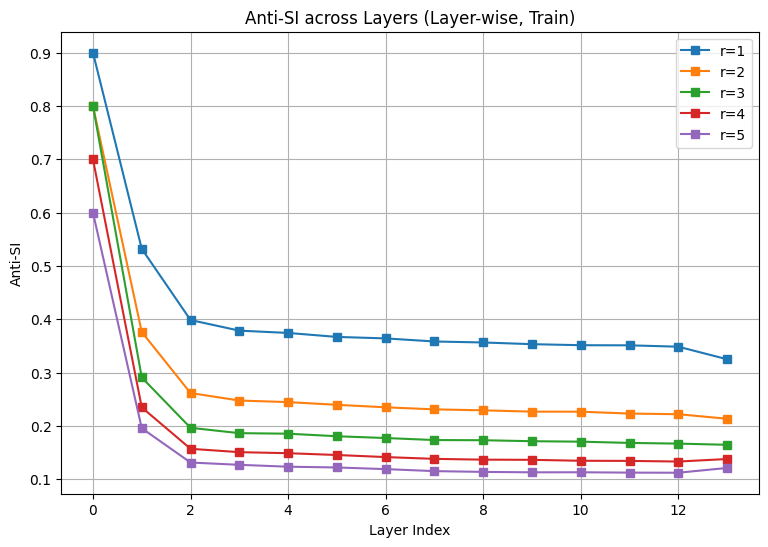

In [24]:
r_values = [1, 2, 3, 4, 5]

center_si_e2e = []
anti_si_e2e = {r: [] for r in r_values}

for i, feats in enumerate(train_feats_e2e):
    csi = compute_center_si(feats, train_labels)
    center_si_e2e.append(csi)

    for r in r_values:
        asi = compute_anti_si(feats, train_labels, r=r)
        anti_si_e2e[r].append(asi)

center_si_lw = []
anti_si_lw = {r: [] for r in r_values}

for i, feats in enumerate(train_feats_lw):
    csi = compute_center_si(feats, train_labels)
    center_si_lw.append(csi)

    for r in r_values:
        asi = compute_anti_si(feats, train_labels, r=r)
        anti_si_lw[r].append(asi)



layers = range(len(center_si_e2e))
print("End-to-End vs Layer-wise Center-SI")
plt.figure(figsize=(8,5))
plt.plot(layers, center_si_e2e, marker='o', label='End-to-End')
plt.plot(layers, center_si_lw, marker='s', label='Layer-wise')
plt.xlabel('Layer Index')
plt.ylabel('Center-SI')
plt.title('Center-SI across Layers (Train Data)')
plt.legend()
plt.grid(True)
plt.show()

print("End-to-End Anti-SI")
plt.figure(figsize=(9,6))
for r in r_values:
    plt.plot(layers, anti_si_e2e[r], marker='o', label=f'r={r}')

plt.xlabel('Layer Index')
plt.ylabel('Anti-SI')
plt.title('Anti-SI across Layers (End-to-End, Train)')
plt.legend()
plt.grid(True)
plt.show()

print("Layer-wise Anti-SI")
plt.figure(figsize=(9,6))
for r in r_values:
    plt.plot(layers, anti_si_lw[r], marker='s', label=f'r={r}')

plt.xlabel('Layer Index')
plt.ylabel('Anti-SI')
plt.title('Anti-SI across Layers (Layer-wise, Train)')
plt.legend()
plt.grid(True)
plt.show()